# Eksperimen Dataset Diabetes

## 1. Perkenalan & Deskripsi Dataset

Dataset yang digunakan pada eksperimen ini adalah **Diabetes Dataset** yang diperoleh dari Kaggle.

Sumber dataset: [Diabetes Dataset - Kaggle](https://www.kaggle.com/datasets/johndasilva/diabetes)

Dataset ini merupakan data tabular yang berisi informasi medis pasien dan digunakan untuk memprediksi kemungkinan seseorang terkena diabetes. Dataset terdiri dari 2000 baris data dan 9 kolom. Seluruh kolom memiliki nilai non-null, sehingga tidak ditemukan missing value secara eksplisit.

Permasalahan yang diselesaikan pada dataset ini adalah klasifikasi biner. Kolom target yang digunakan adalah `Outcome`, dengan nilai:

- `0`: pasien tidak terindikasi diabetes
- `1`: pasien terindikasi diabetes

## Fitur Dataset

| Kolom | Deskripsi | Tipe Data |
|---|---|---|
| Pregnancies | Jumlah kehamilan | int64 |
| Glucose | Kadar glukosa | int64 |
| BloodPressure | Tekanan darah | int64 |
| SkinThickness | Ketebalan kulit | int64 |
| Insulin | Kadar insulin | int64 |
| BMI | Indeks massa tubuh | float64 |
| DiabetesPedigreeFunction | Faktor riwayat diabetes berdasarkan keturunan | float64 |
| Age | Usia pasien | int64 |
| Outcome | Label target diabetes | int64 |

Tujuan dari eksperimen ini adalah melakukan eksplorasi data, memahami karakteristik dataset, menangani potensi nilai tidak realistis pada beberapa fitur medis, melakukan standarisasi fitur numerik, serta menghasilkan dataset yang siap digunakan untuk pelatihan model machine learning.

## 2. Import Library

In [1]:
# Import library utama
import pandas as pd
import numpy as np

# Library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Library tambahan
import os
import warnings
warnings.filterwarnings("ignore")

## 3. Memuat Dataset

In [2]:
# Path dataset
dataset_path = "../diabetes_raw/diabetes.csv"

# Memuat dataset
df = pd.read_csv(dataset_path)

# Menampilkan 5 data pertama
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [3]:
# Melihat ukuran dataset
df.shape

(2000, 9)

In [4]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [5]:
# Melihat statistik deskriptif
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


## 4. Exploratory Data Analysis atau EDA

In [6]:
# Mengecek missing value
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Mengecek data duplikat
df.duplicated().sum()

np.int64(1256)

In [8]:
# Melihat distribusi target
df["Outcome"].value_counts()

Outcome
0    1316
1     684
Name: count, dtype: int64

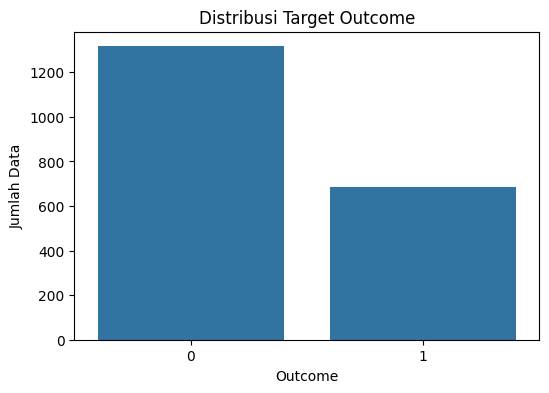

In [9]:
# Visualisasi distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Outcome")
plt.title("Distribusi Target Outcome")
plt.xlabel("Outcome")
plt.ylabel("Jumlah Data")
plt.show()

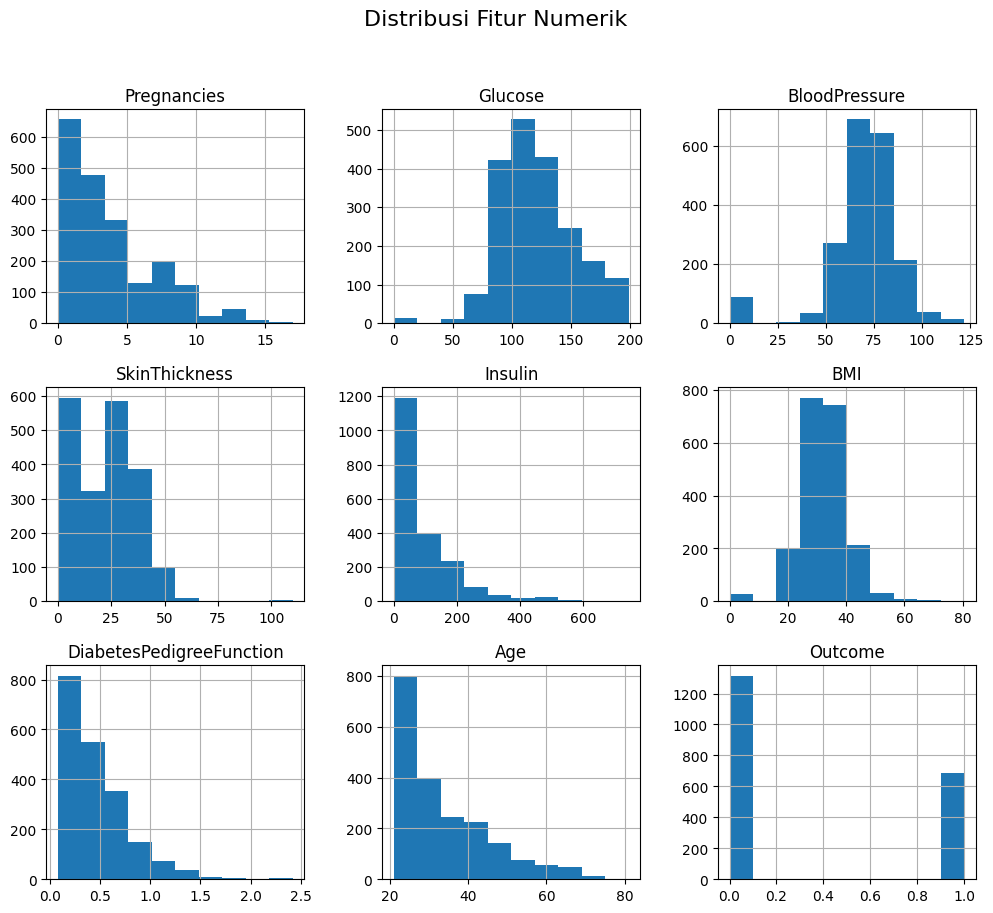

In [10]:
# Visualisasi distribusi setiap fitur numerik
df.hist(figsize=(12, 10))
plt.suptitle("Distribusi Fitur Numerik", fontsize=16)
plt.show()

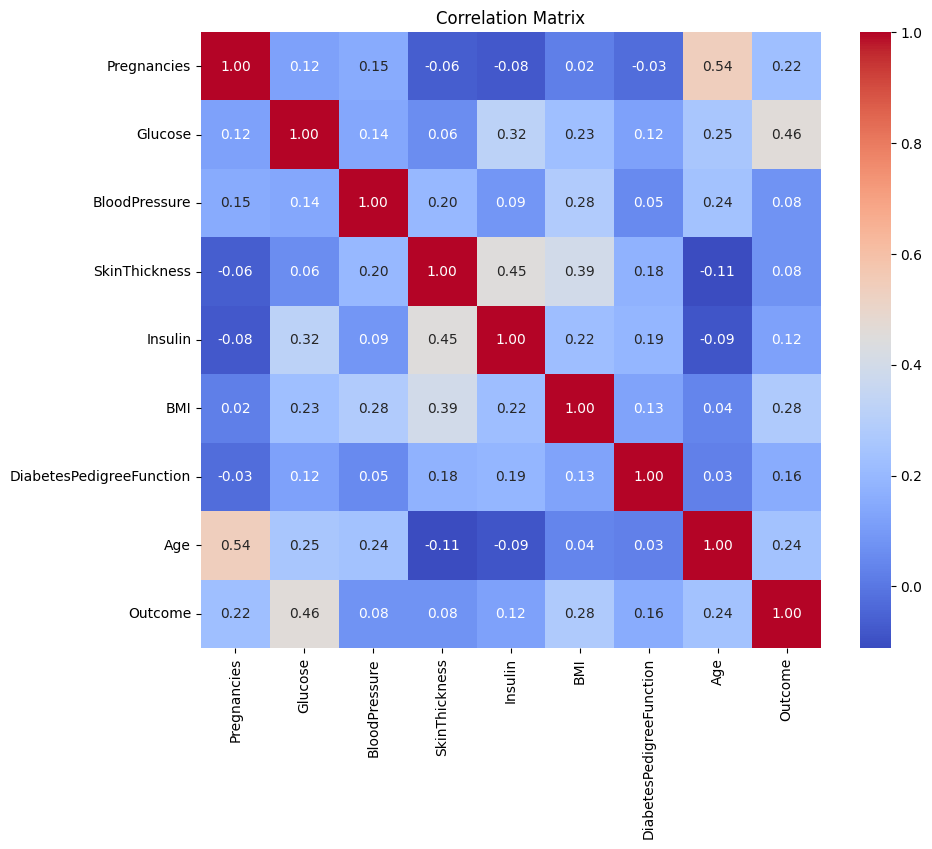

In [11]:
# Korelasi antar fitur
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [12]:
# Mengecek nilai 0 pada kolom yang secara medis seharusnya tidak bernilai 0
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    print(f"{col}: {(df[col] == 0).sum()} nilai 0")

Glucose: 13 nilai 0
BloodPressure: 90 nilai 0
SkinThickness: 573 nilai 0
Insulin: 956 nilai 0
BMI: 28 nilai 0


### Hasil EDA

Berdasarkan hasil Exploratory Data Analysis, dataset memiliki 2000 baris dan 9 kolom. Dataset tidak memiliki missing value secara eksplisit, tetapi ditemukan 1256 data duplikat.

Distribusi target pada dataset adalah sebagai berikut:

- Outcome 0: 1316 data
- Outcome 1: 684 data

Selain itu, ditemukan nilai 0 pada beberapa fitur medis, yaitu:

- Glucose: 13 nilai 0
- BloodPressure: 90 nilai 0
- SkinThickness: 573 nilai 0
- Insulin: 956 nilai 0
- BMI: 28 nilai 0

Nilai 0 pada fitur-fitur tersebut dianggap kurang realistis secara medis sehingga ditangani pada tahap preprocessing.

## 5. Data Preprocessing

Tahapan preprocessing yang dilakukan meliputi:

1. Menghapus 1256 data duplikat.
2. Mengecek nilai 0 pada beberapa fitur medis.
3. Mengganti nilai 0 pada kolom `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` menjadi NaN.
4. Mengisi nilai NaN menggunakan median dari masing-masing kolom.
5. Memisahkan fitur dan target.
6. Membagi dataset menjadi data latih dan data uji dengan rasio 80:20.
7. Melakukan standarisasi fitur numerik menggunakan StandardScaler.
8. Menyimpan hasil preprocessing ke dalam file CSV.

In [13]:
# Membuat salinan dataset agar data asli tetap aman
df_clean = df.copy()

In [14]:
# Menghapus data duplikat jika ada
df_clean = df_clean.drop_duplicates()

# Mengecek ulang jumlah duplikat
df_clean.duplicated().sum()

np.int64(0)

In [15]:
print("Ukuran data sebelum menghapus duplikat:", df.shape)
print("Ukuran data setelah menghapus duplikat:", df_clean.shape)
print("Jumlah duplikat setelah dibersihkan:", df_clean.duplicated().sum())

Ukuran data sebelum menghapus duplikat: (2000, 9)
Ukuran data setelah menghapus duplikat: (744, 9)
Jumlah duplikat setelah dibersihkan: 0


In [16]:
# Mengganti nilai 0 pada kolom medis tertentu menjadi NaN
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean[zero_columns] = df_clean[zero_columns].replace(0, np.nan)

# Mengecek missing value setelah nilai 0 diganti menjadi NaN
df_clean.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                34
SkinThickness               215
Insulin                     359
BMI                          10
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [17]:
# Mengisi nilai NaN dengan median masing-masing kolom
for col in zero_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Mengecek ulang missing value
df_clean.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Pada tahap preprocessing, sebanyak 1256 data duplikat dihapus dari dataset. Selanjutnya, nilai 0 pada kolom Glucose, BloodPressure, SkinThickness, Insulin, dan BMI diganti menjadi NaN karena nilai tersebut kurang realistis secara medis. Setelah itu, nilai NaN diisi menggunakan median dari masing-masing kolom agar data tetap dapat digunakan untuk proses pelatihan model.

In [18]:
# Memisahkan fitur dan target
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

print("Ukuran fitur:", X.shape)
print("Ukuran target:", y.shape)

Ukuran fitur: (744, 8)
Ukuran target: (744,)


In [19]:
# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (595, 8)
Ukuran X_test: (149, 8)
Ukuran y_train: (595,)
Ukuran y_test: (149,)


In [20]:
# Standarisasi fitur numerik
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Mengubah hasil scaling menjadi DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Reset index target agar sejajar saat digabungkan
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Menggabungkan kembali fitur dan target
train_data = pd.concat([X_train_scaled, y_train], axis=1)
test_data = pd.concat([X_test_scaled, y_test], axis=1)

# Menggabungkan data train dan test sebagai dataset preprocessing lengkap
diabetes_preprocessed = pd.concat([train_data, test_data], axis=0).reset_index(drop=True)

In [22]:
# Melihat data latih hasil preprocessing
train_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.830577,-0.839100,4.145122,-0.021545,-0.175627,-1.378880,-0.840965,-0.536315,0
1,-0.247802,-0.347956,-1.336943,1.093183,-0.175627,-0.311004,0.265715,-0.279316,0
2,-0.830577,-0.446185,1.321028,-1.136273,-0.175627,-0.727060,-0.230710,-0.793314,0
3,-0.539190,-1.068301,1.487151,0.089928,-0.175627,0.160525,-0.572200,0.748681,0
4,0.334973,0.470618,0.988782,1.316128,-0.667138,0.368553,-0.591171,0.149016,1


In [23]:
# Melihat data uji hasil preprocessing
test_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.043586,0.798047,1.653275,-0.021545,-0.175627,-0.158451,0.208800,2.376344,1
1,-0.830577,-0.871843,-1.004696,-1.247746,-1.055174,-1.170852,-0.673382,-0.964647,0
2,-0.539190,0.208674,0.490412,0.870237,0.548706,1.519639,2.374729,-0.193649,1
3,1.500524,1.125477,1.154905,-0.133018,0.199474,0.271473,2.264062,0.748681,1
4,0.626361,-1.002815,-0.007957,-0.021545,-0.175627,-0.352610,0.088646,-0.193649,0


In [24]:
# Mengecek ukuran akhir dataset hasil preprocessing
print("Ukuran train_data:", train_data.shape)
print("Ukuran test_data:", test_data.shape)
print("Ukuran diabetes_preprocessed:", diabetes_preprocessed.shape)

Ukuran train_data: (595, 9)
Ukuran test_data: (149, 9)
Ukuran diabetes_preprocessed: (744, 9)


In [25]:
# Membuat folder untuk menyimpan hasil preprocessing
output_dir = "diabetes_preprocessing"
os.makedirs(output_dir, exist_ok=True)

# Menyimpan dataset hasil preprocessing
train_data.to_csv(os.path.join(output_dir, "train.csv"), index=False)
test_data.to_csv(os.path.join(output_dir, "test.csv"), index=False)
diabetes_preprocessed.to_csv(os.path.join(output_dir, "diabetes_preprocessed.csv"), index=False)

print("Dataset hasil preprocessing berhasil disimpan.")
print("File train.csv berhasil dibuat.")
print("File test.csv berhasil dibuat.")
print("File diabetes_preprocessed.csv berhasil dibuat.")

Dataset hasil preprocessing berhasil disimpan.
File train.csv berhasil dibuat.
File test.csv berhasil dibuat.
File diabetes_preprocessed.csv berhasil dibuat.


Hasil preprocessing disimpan ke dalam folder `diabetes_preprocessing`. File `train.csv` berisi data latih, `test.csv` berisi data uji, dan `diabetes_preprocessed.csv` berisi gabungan data hasil preprocessing. Dataset ini nantinya digunakan pada tahap pelatihan model machine learning.